In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
df=pd.read_csv("C:\\Users\\Dell\\Desktop\\Project 1\\Ecomerce retail\\Raw Data\\ecommerce_retail_transactions_raw.csv", encoding='latin1')
df.head()

,Order_ID,Customer_ID,Order_Date,Product_Category,Product_Name,Quantity,Unit_Price_USD,Discount_Percent,Payment_Method,Shipping_City,Country,Order_Status,Customer_Rating
0,ORD011416,CUST00003,2026-04-03,Books,Self-Help Book,3,9.16,5.0,Net Banking,London,UK,Delivered,5.0
1,ORD000974,CUST00269,10-15-2024,Books,Fiction Novel,1,34.24,5.0,NetBanking,Toronto,CA,Shipped,NaN
2,ORD000617,CUST02075,17 Jun 2024,Home & Kitchen,Vacuum Cleaner,2,111.95,15.0,DEBIT CARD,Brisbane,Australia,Shipped,NaN
3,ORD006437,CUST02109,16/10/2025,Beauty,Hair Dryer,1,31.84,0.0,Cash on Delivery,Birmingham,U.K.,Delivered,3.0
4,ORD000740,CUST00349,06 Apr 2026,Home & Kitchen,Non-Stick Pan,2,72.00,NaN,Credit_Card,Montreal,CA,Delivered,NaN


In [108]:
# Check Column Names
df.columns

Index(['Order_ID', 'Customer_ID', 'Order_Date', 'Product_Category',
       'Product_Name', 'Quantity', 'Unit_Price_USD', 'Discount_Percent',
       'Payment_Method', 'Shipping_City', 'Country', 'Order_Status',
       'Customer_Rating'],
      dtype='object')

In [109]:
# Replace underscores (_) with space in all column names
df.columns=df.columns.str.replace("_", " ")
df.columns

Index(['Order ID', 'Customer ID', 'Order Date', 'Product Category',
       'Product Name', 'Quantity', 'Unit Price USD', 'Discount Percent',
       'Payment Method', 'Shipping City', 'Country', 'Order Status',
       'Customer Rating'],
      dtype='object')

In [110]:
# Check Missing Values
df.isna().sum()

Order ID               0
Customer ID            0
Order Date             0
Product Category       0
Product Name           0
Quantity               0
Unit Price USD         0
Discount Percent     735
Payment Method         0
Shipping City        502
Country                0
Order Status           0
Customer Rating     6150
dtype: int64

In [111]:
# Filling NAN Values
# Filling Discount Percent with 0 where value is NAN
df["Discount Percent"]=df["Discount Percent"].fillna(0)
# Filling Shipping City with Unknown where value is NAN
df["Shipping City"]=df["Shipping City"].fillna("Unknown")
# Filling Customer Rating with Mode where value is NAN
df["Customer Rating"]=df["Customer Rating"].fillna(df["Customer Rating"].median())

In [112]:
# Check Missing Values again after raplacing NAN values
df.isna().sum()

Order ID            0
Customer ID         0
Order Date          0
Product Category    0
Product Name        0
Quantity            0
Unit Price USD      0
Discount Percent    0
Payment Method      0
Shipping City       0
Country             0
Order Status        0
Customer Rating     0
dtype: int64

In [113]:
# Check Whether Quantity is Negative or Not
df["Quantity"].describe()

count    12180.000000
mean         2.019458
std          1.234956
min         -1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Quantity, dtype: float64

In [114]:
# Creting Function which will make negative value to positive and zero to 1
def valid_qty(x):
    if x<0:
        return abs(x)
    elif x==0:
        return 1
    else:
        return x
# Applying Function on Quantity
df["Quantity"]=df["Quantity"].apply(valid_qty)

In [115]:
# Check Whether Quantity is Negative or Not after changing nagative or zero value
df["Quantity"].describe()

count    12180.000000
mean         2.043514
std          1.197849
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          5.000000
Name: Quantity, dtype: float64

In [116]:
# Check duplicate value on the basis of orde id
df["Order ID"].duplicated().sum()

np.int64(180)

In [117]:
# Delete duplicate value on the basis of order id
df=df.drop_duplicates(subset=["Order ID"], keep="first")

In [118]:
# Check duplicate value on the basis of orde id after deleting duplicates
df["Order ID"].duplicated().sum()

np.int64(0)

In [119]:
df.head()

,Order ID,Customer ID,Order Date,Product Category,Product Name,Quantity,Unit Price USD,Discount Percent,Payment Method,Shipping City,Country,Order Status,Customer Rating
0,ORD011416,CUST00003,2026-04-03,Books,Self-Help Book,3,9.16,5.0,Net Banking,London,UK,Delivered,5.0
1,ORD000974,CUST00269,10-15-2024,Books,Fiction Novel,1,34.24,5.0,NetBanking,Toronto,CA,Shipped,4.0
2,ORD000617,CUST02075,17 Jun 2024,Home & Kitchen,Vacuum Cleaner,2,111.95,15.0,DEBIT CARD,Brisbane,Australia,Shipped,4.0
3,ORD006437,CUST02109,16/10/2025,Beauty,Hair Dryer,1,31.84,0.0,Cash on Delivery,Birmingham,U.K.,Delivered,3.0
4,ORD000740,CUST00349,06 Apr 2026,Home & Kitchen,Non-Stick Pan,2,72.00,0.0,Credit_Card,Montreal,CA,Delivered,4.0


In [120]:
# Column Name which need to change formating
column=[
    "Product Category",
    "Product Name",
    "Payment Method",
    "Shipping City",
    "Country",
    "Order Status"
]
# Now Changing Formating of column elements with the help of loop
for i in column:
    df[i]=df[i].str.strip().str.title().str.replace("_", " ")

In [121]:
df.head()

,Order ID,Customer ID,Order Date,Product Category,Product Name,Quantity,Unit Price USD,Discount Percent,Payment Method,Shipping City,Country,Order Status,Customer Rating
0,ORD011416,CUST00003,2026-04-03,Books,Self-Help Book,3,9.16,5.0,Net Banking,London,Uk,Delivered,5.0
1,ORD000974,CUST00269,10-15-2024,Books,Fiction Novel,1,34.24,5.0,Netbanking,Toronto,Ca,Shipped,4.0
2,ORD000617,CUST02075,17 Jun 2024,Home & Kitchen,Vacuum Cleaner,2,111.95,15.0,Debit Card,Brisbane,Australia,Shipped,4.0
3,ORD006437,CUST02109,16/10/2025,Beauty,Hair Dryer,1,31.84,0.0,Cash On Delivery,Birmingham,U.K.,Delivered,3.0
4,ORD000740,CUST00349,06 Apr 2026,Home & Kitchen,Non-Stick Pan,2,72.00,0.0,Credit Card,Montreal,Ca,Delivered,4.0


In [122]:
# Check data is repeated or not cause of different format
df["Country"].value_counts()

Country
Uae               1170
Australia         1167
Germany           1160
India             1115
Canada            1096
Uk                 885
Usa                727
De                 587
In                 575
U.A.E              572
Au                 540
Ca                 539
U.K.               444
United Kingdom     439
United States      341
Us                 335
U.S.A              308
Name: count, dtype: int64

In [123]:
# Creating a dictionary which will store one format for each country
country={
    "Uae":"UAE", "U.A.E":"UAE",
    "Au":"Australia",
    "De":"Germany",
    "In":"India",
    "Ca":"Canada",
    "Uk":"UK", "U.K.":"UK", "United Kingdom":"UK",
    "Usa":"USA", "United States":"USA", "Us":"USA", "U.S.A": "USA"
}
# Appllying single formating for each country
df["Country"]=df["Country"].replace(country)

In [124]:
# Check data is repeated or not cause of different format after applying formating
df["Country"].value_counts()

Country
UK           1768
Germany      1747
UAE          1742
USA          1711
Australia    1707
India        1690
Canada       1635
Name: count, dtype: int64

In [125]:
# Check data is repeated or not cause of different format in payment
df["Payment Method"].value_counts()

Payment Method
Credit Card         2031
Debit Card          1910
Paypal              1390
Net Banking         1375
Upi                 1293
Cod                 1049
Cash On Delivery    1021
Netbanking           650
Pay Pal              643
U.P.I                638
Name: count, dtype: int64

In [126]:
# Make one format for each Payment Type
payment_format={
    "Pay Pal":"Paypal",
    "Net Banking":"Netbanking",
    "Upi":"UPI", "U.P.I":"UPI",
    "Cod":"Cash On Delivery"
}
# Appllying single formating for each payment types
df["Payment Method"]=df["Payment Method"].replace(payment_format)

In [127]:
# Check data is repeated or not cause of different format in payment after aplying format
df["Payment Method"].value_counts()

Payment Method
Cash On Delivery    2070
Paypal              2033
Credit Card         2031
Netbanking          2025
UPI                 1931
Debit Card          1910
Name: count, dtype: int64

### Now Inserting new column which will help to analyze the data

In [128]:
# To replace float value into percentage(decimal) value in discount
df["Discount Percent"]=df["Discount Percent"]/100
# Add Sales Amount column by multiply unit price and qty
df["Sales Amount"]=df["Unit Price USD"]*df["Quantity"]
# Add Total Amount column after discount
df["Total Amount"]=df["Sales Amount"]*(1-df["Discount Percent"])

In [129]:
# Convert "Order Date" to datetime 
df["Order Date"]=pd.to_datetime(df["Order Date"], format="mixed")
# Adding New Columns for check trend over year
df["Year"]=df["Order Date"].dt.year
df["Month"]=df["Order Date"].dt.month

In [130]:
# Reform as a str "DD-MM-YYYY"
df["Order Date"]=df["Order Date"].dt.strftime("%d-%m-%Y")

In [131]:
df.head()

,Order ID,Customer ID,Order Date,Product Category,Product Name,Quantity,Unit Price USD,Discount Percent,Payment Method,Shipping City,Country,Order Status,Customer Rating,Sales Amount,Total Amount,Year,Month
0,ORD011416,CUST00003,03-04-2026,Books,Self-Help Book,3,9.16,0.05,Netbanking,London,UK,Delivered,5.0,27.48,26.106,2026,4
1,ORD000974,CUST00269,15-10-2024,Books,Fiction Novel,1,34.24,0.05,Netbanking,Toronto,Canada,Shipped,4.0,34.24,32.528,2024,10
2,ORD000617,CUST02075,17-06-2024,Home & Kitchen,Vacuum Cleaner,2,111.95,0.15,Debit Card,Brisbane,Australia,Shipped,4.0,223.90,190.315,2024,6
3,ORD006437,CUST02109,16-10-2025,Beauty,Hair Dryer,1,31.84,0.00,Cash On Delivery,Birmingham,UK,Delivered,3.0,31.84,31.840,2025,10
4,ORD000740,CUST00349,06-04-2026,Home & Kitchen,Non-Stick Pan,2,72.00,0.00,Credit Card,Montreal,Canada,Delivered,4.0,144.00,144.000,2026,4


### Creating KPIs (Key Performance Indicator)

In [132]:
# Business And Sales KPIs (Revenue Growth & Discount)
total_sales=df["Total Amount"].sum() 
total_orders=df["Order ID"].nunique() 
average_order_value=total_sales/total_orders 
total_customers=df["Customer ID"].nunique()
average_customer_rating=df["Customer Rating"].sum()/len(df)
total_sold_quantity=df["Quantity"].sum()
total_discount=df["Sales Amount"].sum()-total_sales
average_discount=df["Discount Percent"].mean()*100
average_items_per_order=df["Quantity"].mean()
delivered_orders=df[df["Order Status"]=="Delivered"]["Order ID"].nunique()
delivery_rate=delivered_orders/total_orders*100



# Customer Performane KPIs (Retention & Value)
revenue_per_customer=df["Total Amount"].sum()/df["Customer ID"].nunique()
customer_order=df.groupby("Customer ID")["Order ID"].nunique()
repeat_customer=(customer_order > 1).sum()
repeat_rate=(repeat_customer/df["Customer ID"].nunique()*100)





In [133]:
print("=" * 40)
print("""-----Business and Sales KPIs-----
----(Revenue Growth & Discount)----""")
print("=" * 40)
print(f"Total Revenue: ${total_sales/1000000:,.2f}M")
print(f"Total Orders: {total_orders/1000:,.2f}K")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Sold Quantity: {total_sold_quantity/1000:,.2f}k")
print(f"Total Discoun Amount: ${total_discount/1000:,.2f}k")
print(f"Average Discount in Percentage: {average_discount:,.2f}%")
print(f"Average Items per Order: {average_items_per_order:,.0f}")
print(f"Delivered Order: {delivered_orders:,.0f}")
print(f"Delivery Rate: {delivery_rate:,.2f}%")
print()


print("=" * 40)
print("""----Customer Performane KPIs----
------(Retention & Value)------""")
print("=" * 40)
print(f"Average Customer Rating: {average_customer_rating:,.2f}")
print(f"Total Cutomers: {total_customers/1000:,.3f}K")
print(f"Average Revenue Per Customer: ${revenue_per_customer:,.2f}")
print(f"Repeated Customer: {repeat_customer/1000:,.2f}K")
print(f"Repeat Rate: {repeat_rate:,.2f}%")



-----Business and Sales KPIs-----
----(Revenue Growth & Discount)----
Total Revenue: $1.41M
Total Orders: 12.00K
Average Order Value: $117.38
Total Sold Quantity: 24.51k
Total Discoun Amount: $103.25k
Average Discount in Percentage: 6.87%
Average Items per Order: 2
Delivered Order: 6,578
Delivery Rate: 54.82%

----Customer Performane KPIs----
------(Retention & Value)------
Average Customer Rating: 3.95
Total Cutomers: 3.374K
Average Revenue Per Customer: $417.46
Repeated Customer: 2.98K
Repeat Rate: 88.47%


### Visualization

### Yearly & Monthly Sales Trend (Line Plot)

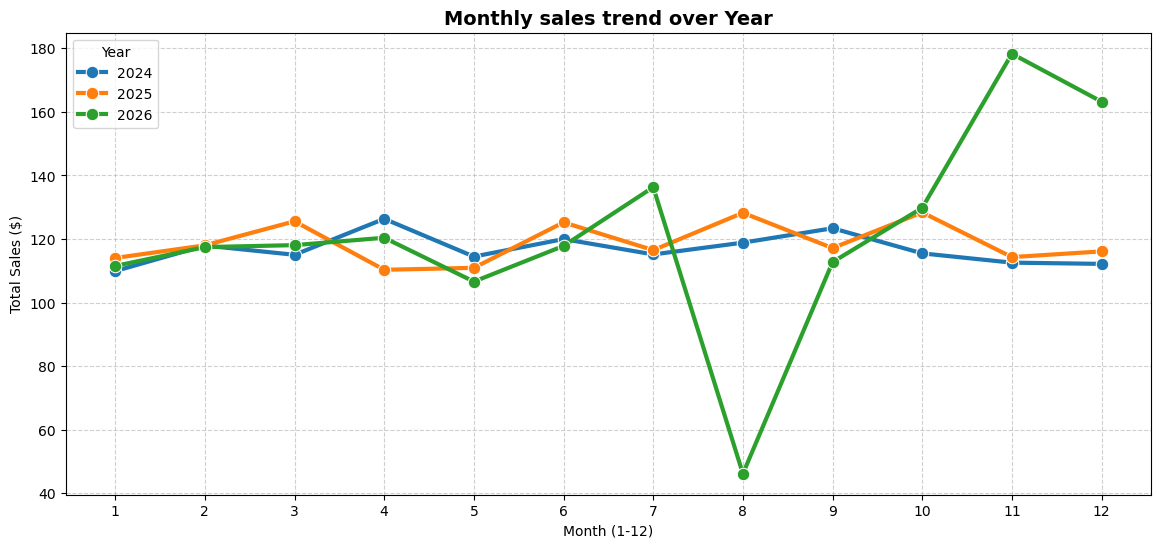

In [134]:
plt.figure(figsize=(14,6))
sns.lineplot(
    x="Month",
    y="Total Amount",
    hue="Year",
    data=df,
    marker="o",
    palette="tab10",
    errorbar=None,
    linewidth=3,
    markersize=9
)
plt.title(
    "Monthly sales trend over Year",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Month (1-12)")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1,13))
plt.grid(True, linestyle="--", alpha=0.6)
plt.savefig('1_monthly_sales_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### Top Product Categories by Revenue (Bar Chart)

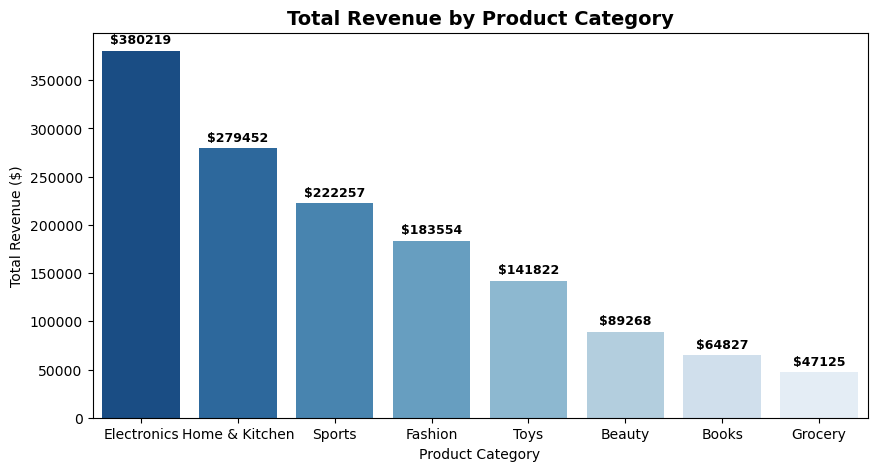

In [135]:
plt.figure(figsize=(10,5))
category_sales=df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False).reset_index()

ax=sns.barplot(
    x="Product Category",
    y="Total Amount",
    data=category_sales,
    hue="Product Category",
    legend=False,
    palette="Blues_r"
)
for i in ax.containers:
    ax.bar_label(
        i,
        fmt="$%.0f",
        padding=3,
        fontweight="bold",
        fontsize=9
)
plt.title(
    "Total Revenue by Product Category",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue ($)")
plt.savefig('2_revenue_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

### Country Wise Revenue (Bar Chart)

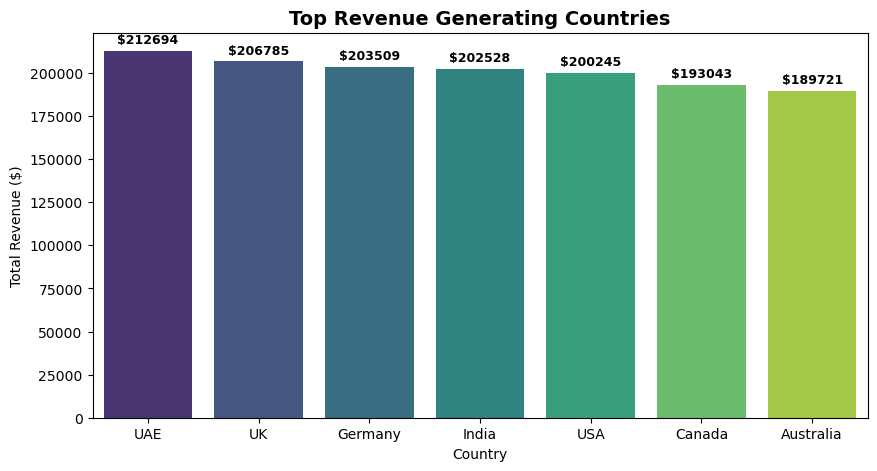

In [136]:
plt.figure(figsize=(10,5))
country_sales=df.groupby("Country")["Total Amount"].sum().sort_values(ascending=False).reset_index()

ax=sns.barplot(
    x="Country",
    y="Total Amount",
    hue="Country",
    data=country_sales,
    palette="viridis"
)
for i in ax.containers:
    ax.bar_label(
        i,
        fmt="$%.0f",
        padding=3,
        fontweight="bold",
        fontsize=9
)
plt.title(
    "Top Revenue Generating Countries",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Country")
plt.ylabel("Total Revenue ($)")
plt.savefig('3_country_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

### Preferred Payment Methods (Pie Chart)

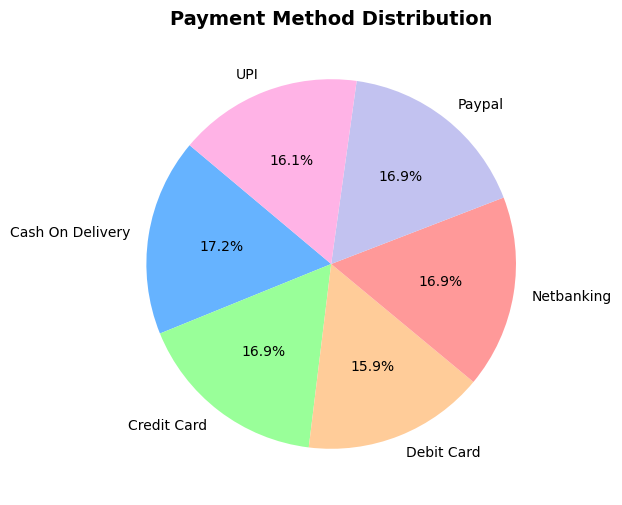

In [137]:
plt.figure(figsize=(6,6))
payment_types=df.groupby("Payment Method")["Payment Method"].value_counts()

plt.pie(
    payment_types,
    labels=payment_types.index,
    autopct="%1.1f%%",
    colors=["#66b3ff", "#99ff99", "#ffcc99", "#ff9999", "#c2c2f0", "#ffb3e6"],
    startangle=140
)
plt.title(
    "Payment Method Distribution",
    fontsize=14,
    fontweight="bold"
)
plt.savefig('4_payment_method_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Order Status Breakdown (Count Plot)

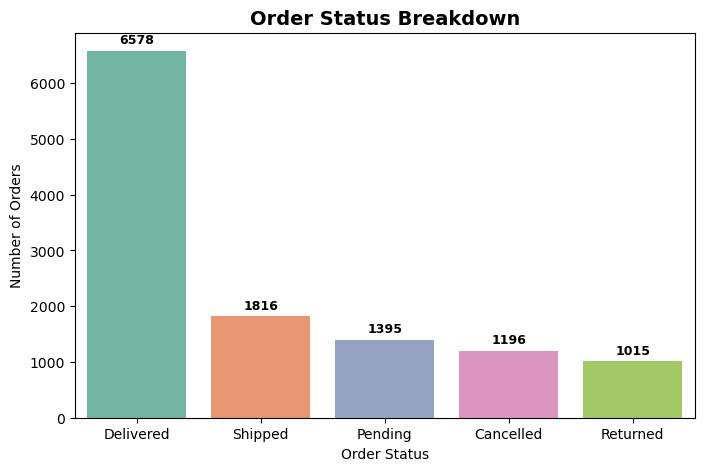

In [138]:
plt.figure(figsize=(8,5))
order_status=df.groupby("Order Status")["Order ID"].count().sort_values(ascending=False).reset_index()

ax=sns.barplot(
    x="Order Status",
    y="Order ID",
    data=order_status,
    hue="Order Status",
    palette="Set2"
)
for i in ax.containers:
    ax.bar_label(
        i,
        fmt="%.0f",
        padding=3,
        fontweight="bold",
        fontsize=9
)
plt.title(
    "Order Status Breakdown",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.savefig('5_order_status_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()


### Top 10 Revenue Generating Cities

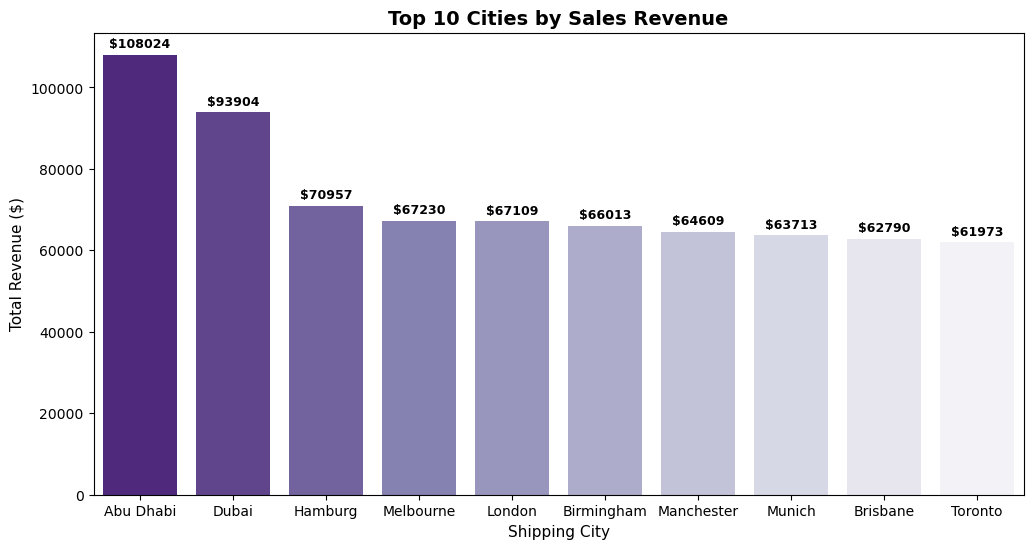

In [139]:
plt.figure(figsize=(12,6))
top_cities=df.groupby("Shipping City")["Total Amount"].sum().sort_values(ascending=False).head(10).reset_index()

ax=sns.barplot(
    x="Shipping City",
    y="Total Amount",
    data=top_cities,
    hue="Shipping City",
    palette="Purples_r",
    legend=False
)
for i in ax.containers:
    ax.bar_label(
        i,
        fmt="$%.0f",
        padding=3,
        fontweight="bold",
        fontsize=9
)
plt.title(
    "Top 10 Cities by Sales Revenue",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Shipping City",
    fontsize=11
)
plt.ylabel(
    "Total Revenue ($)",
    fontsize=11
)
plt.savefig('6_top_cities_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

### Top 10 Selling Products

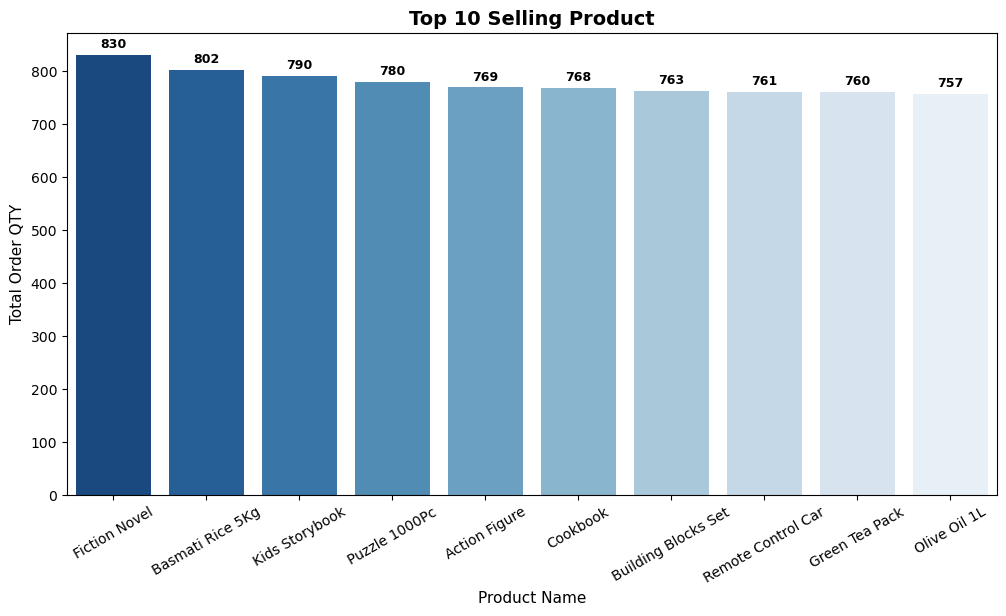

In [140]:
plt.figure(figsize=(12,6))
top_product=df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False).head(10).reset_index()

ax=sns.barplot(
    x="Product Name",
    y="Quantity",
    data=top_product,
    hue="Product Name",
    palette="Blues_r",
    legend=False,
    
)
for i in ax.containers:
    ax.bar_label(
        i,
        fmt="%.0f",
        padding=3,
        fontweight="bold",
        fontsize=9
)
plt.title(
    "Top 10 Selling Product",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel(
    "Product Name",
    fontsize=11
)
plt.ylabel(
    "Total Order QTY",
    fontsize=11
)
plt.xticks(rotation=30)
plt.savefig('7_top_selling_products.png', dpi=300, bbox_inches='tight')
plt.show()

### Unit Price Vs Revenue

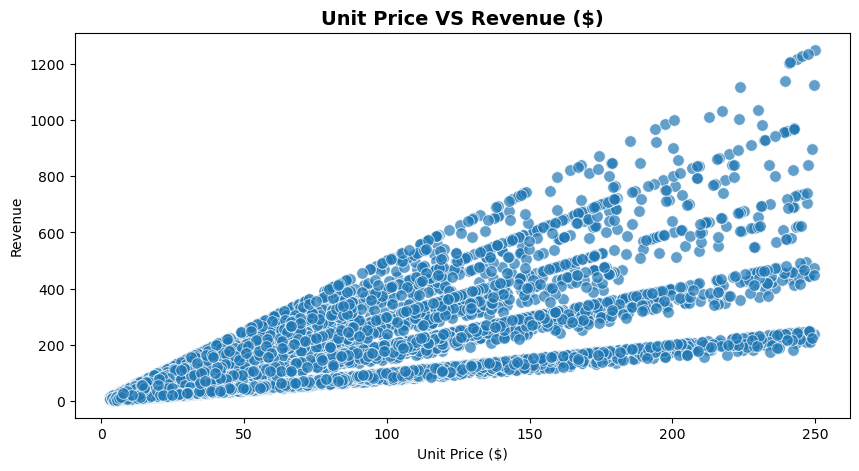

In [141]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x="Unit Price USD",
    y="Total Amount",
    data=df,
    alpha=0.7,
    s=70,
    legend=False
)
plt.title(
    "Unit Price VS Revenue ($)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Unit Price ($)")
plt.ylabel("Revenue")
plt.savefig('8_unit_price_vs_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

### Heatmap to check Correlation

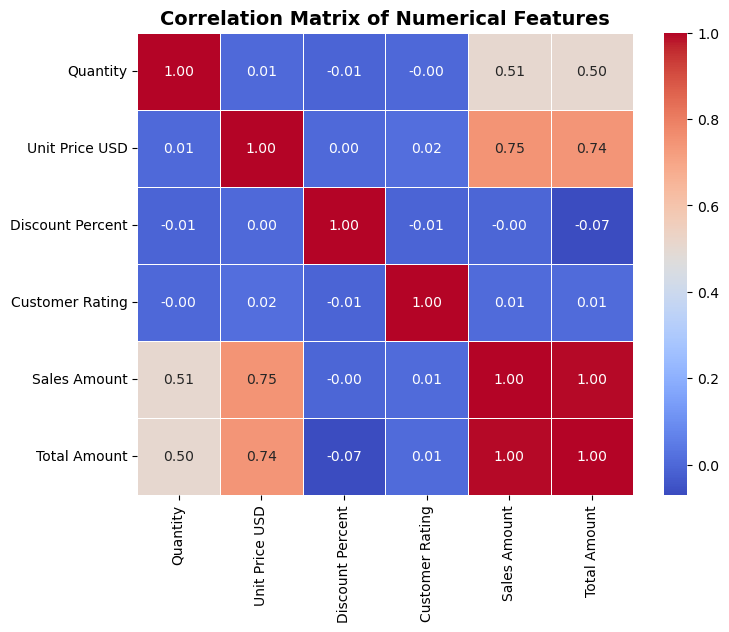

In [142]:
plt.figure(figsize=(8,6))
num_cols=df.select_dtypes(include=["float64", "int64"]).columns
corr=df[num_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt='.2f',
    linewidths=0.5
)
plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=14,
    fontweight="bold"
)
plt.savefig('9_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [143]:
# To save clean Data
df.to_csv("C:\\Users\\Dell\\Desktop\\Project 1\\Ecomerce Sales\\ecommerce_retail_transactions_cleaned.csv", index=False)